# 05 · Evaluation, Explainability & Monitoring

In [1]:
import sys
sys.path.insert(0, "..")

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

from src.metrics import evaluate, psi

In [2]:
df = pd.read_csv("../data/preprocessed_train.csv")
X = df.drop(columns=["SK_ID_CURR", "TARGET"]).astype("float32")   # float32 halves memory
y = df["TARGET"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

model = joblib.load("../models/best_model.pkl")
y_prob = model.predict_proba(X_test)[:, 1]

# 1. Financial metrics

In [3]:
evaluate(y_test, y_prob).round(4).to_frame("Value")

,Value
AUROC,0.7705
Gini,0.5410
KS,0.4068
AUPRC,0.2630
F1,0.3228
F1_threshold,0.6811


**AUROC 0.771 (Gini 0.541)** is above the 0.72 target; **KS 0.41** is above the usual 0.30 bar; **AUPRC 0.263** is 3.3× the random baseline (0.081). The best-F1 threshold is 0.68, not 0.5, because `class_weight="balanced"` inflates the scores.

# 2. Cross-validation

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")
print("Fold scores:", cv_scores.round(4))
print(f"Mean AUROC: {cv_scores.mean():.4f}   Std: {cv_scores.std():.4f}")

Fold scores: [0.7642 0.7637 0.7647 0.7665 0.764 ]
Mean AUROC: 0.7646   Std: 0.0010


# 3. SHAP (1,000 test applicants)

In [5]:
X_shap = X_test.sample(1000, random_state=42)
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_shap)
np.save("../models/shap_values.npy", shap_values.values)

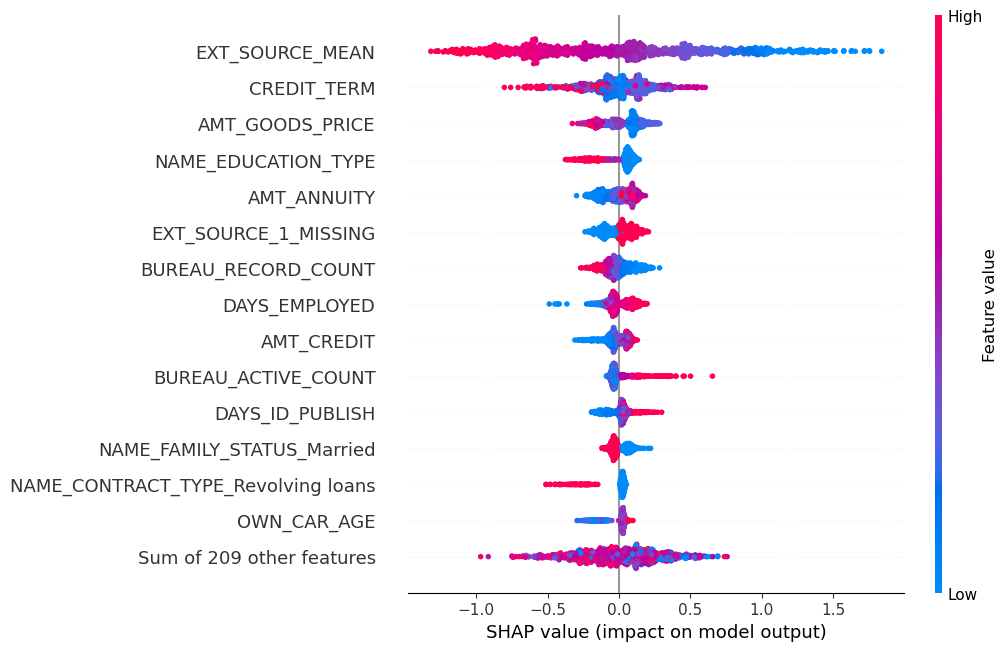

In [6]:
shap.plots.beeswarm(shap_values, max_display=15)

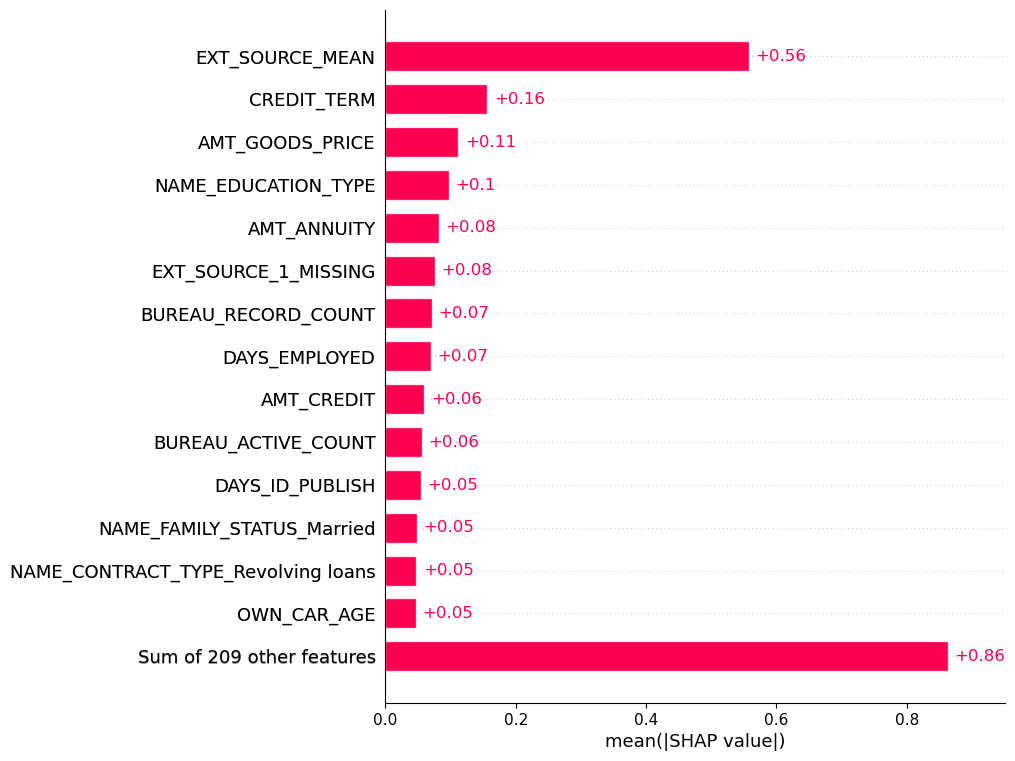

In [7]:
shap.plots.bar(shap_values, max_display=15)

**`EXT_SOURCE_MEAN` dominates**: low external scores push strongly towards default. Next come `CREDIT_TERM`, goods price, education and annuity. 5 of the top 10 are engineered features (`EXT_SOURCE_MEAN`, `CREDIT_TERM`, `EXT_SOURCE_1_MISSING`, `BUREAU_RECORD_COUNT`, `BUREAU_ACTIVE_COUNT`).

# 4. Three applicants: high risk, borderline, low risk
Scores are inflated by `class_weight="balanced"`, so they are risk scores rather than true probabilities.

In [8]:
scores = pd.Series(y_prob, index=X_test.index).loc[X_shap.index]
picks = {
    "high risk (> 0.5)": scores[scores > 0.5].index[0],
    "borderline (0.2-0.4)": scores[scores.between(0.2, 0.4)].index[0],
    "low risk (< 0.1)": scores[scores < 0.1].index[0],
}
for name, idx in picks.items():
    print(f"{name}: score {scores[idx]:.3f}, defaulted = {bool(y[idx])}")

high risk (> 0.5): score 0.533, defaulted = False
borderline (0.2-0.4): score 0.385, defaulted = True
low risk (< 0.1): score 0.100, defaulted = False


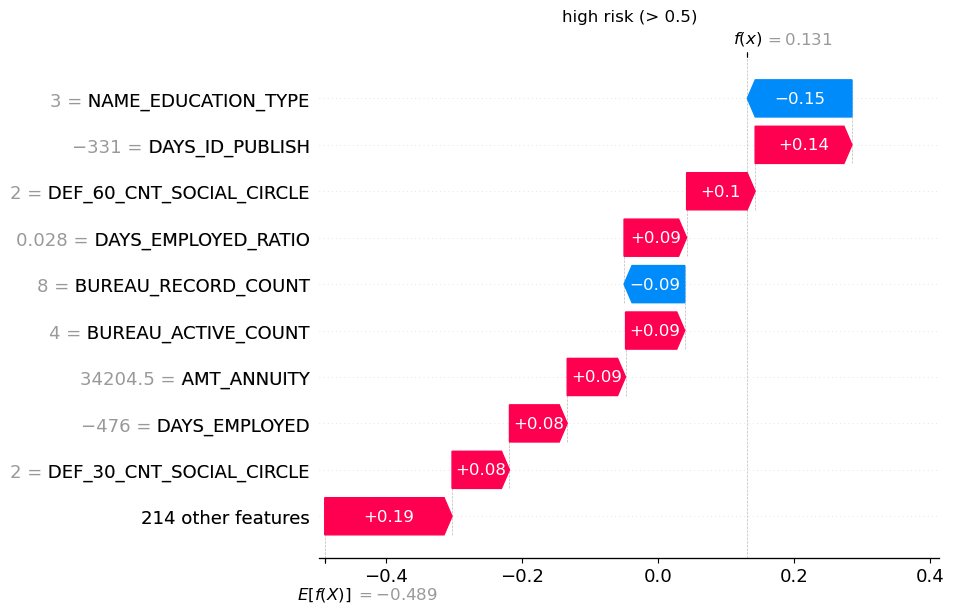

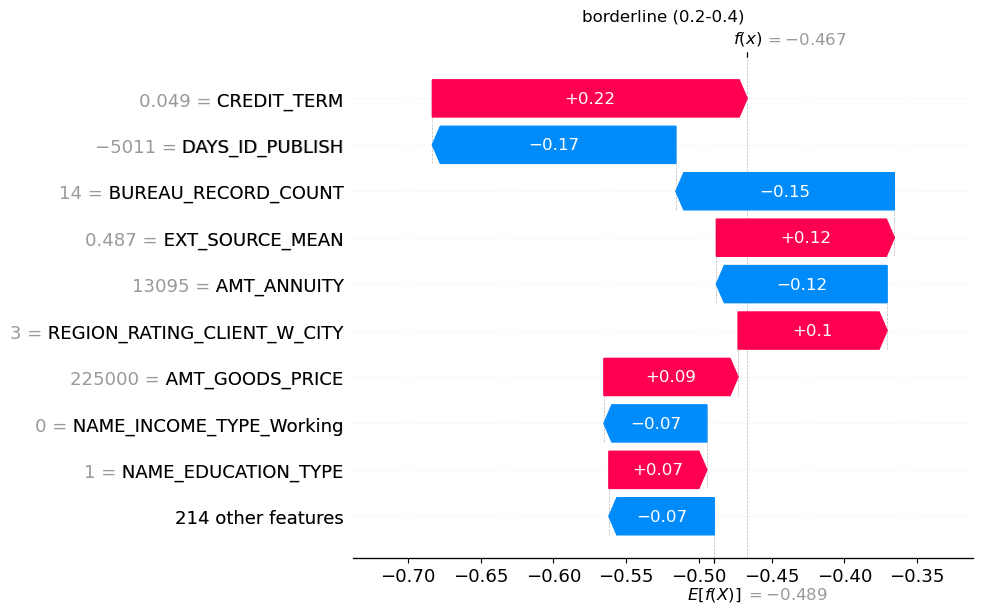

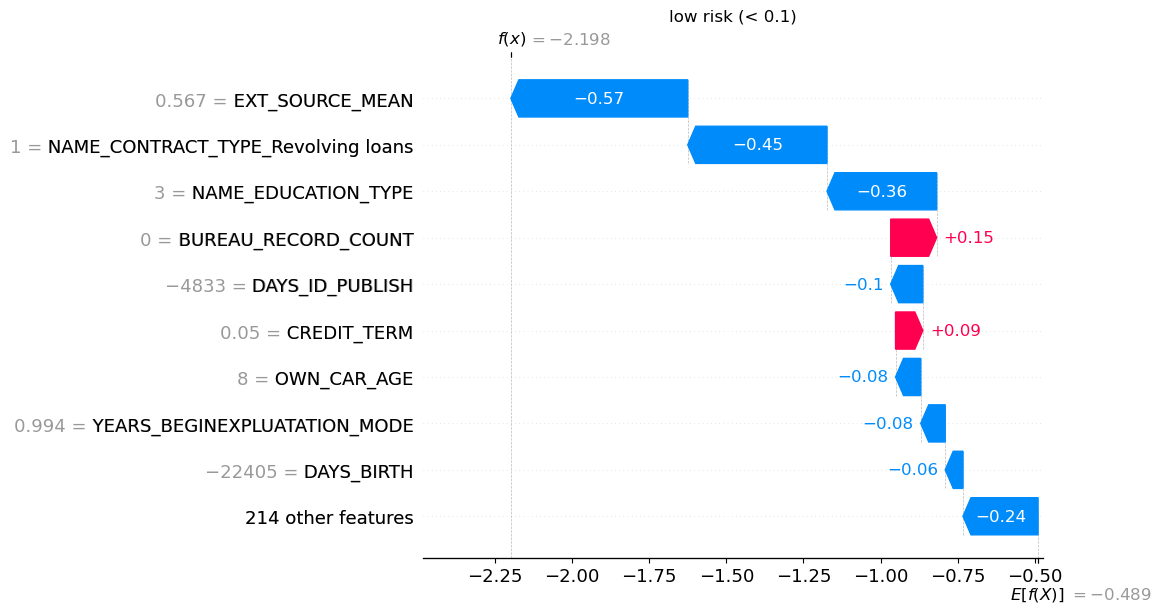

In [9]:
for name, idx in picks.items():
    shap.plots.waterfall(shap_values[X_shap.index.get_loc(idx)], max_display=10, show=False)
    plt.title(name)
    plt.show()

Each waterfall starts at the average model output and each bar is one feature's push for this applicant (red = towards default, blue = towards repayment). The high-risk applicant (score 0.53) actually repaid, while the borderline one (0.39) defaulted: a score is a probability, not a verdict.

# 5. Adverse action notice - top 4 reasons for the high-risk applicant

In [10]:
i = X_shap.index.get_loc(picks["high risk (> 0.5)"])
reasons = pd.DataFrame({
    "applicant value": X_shap.iloc[i],
    "typical repaid applicant": X_train[y_train == 0].median(),
    "SHAP": shap_values.values[i],
})
top4 = reasons[reasons["SHAP"] > 0].sort_values("SHAP", ascending=False).head(4)
top4.round(3)

,applicant value,typical repaid applicant,SHAP
DAYS_ID_PUBLISH,-331.000,-3295.000,0.142
DEF_60_CNT_SOCIAL_CIRCLE,2.000,0.000,0.101
DAYS_EMPLOYED_RATIO,0.028,0.092,0.092
BUREAU_ACTIVE_COUNT,4.000,1.000,0.087


In [11]:
print("Main reasons your application was declined:")
for n, (feature, row) in enumerate(top4.iterrows(), 1):
    print(f"{n}. {feature} is {row['applicant value']:,.2f} "
          f"(applicants who repaid typically have {row['typical repaid applicant']:,.2f})")

Main reasons your application was declined:
1. DAYS_ID_PUBLISH is -331.00 (applicants who repaid typically have -3,295.00)
2. DEF_60_CNT_SOCIAL_CIRCLE is 2.00 (applicants who repaid typically have 0.00)
3. DAYS_EMPLOYED_RATIO is 0.03 (applicants who repaid typically have 0.09)
4. BUREAU_ACTIVE_COUNT is 4.00 (applicants who repaid typically have 1.00)


# 6. PSI for the top 10 features
PSI < 0.10 stable, 0.10–0.25 watch, > 0.25 significant shift → review.

In [12]:
importance = pd.Series(np.abs(shap_values.values).mean(axis=0), index=X_shap.columns).sort_values(ascending=False)
top10 = importance.head(10).index

psi_table = pd.DataFrame({"PSI": [psi(X_train[f], X_test[f]) for f in top10]}, index=top10)
psi_table["Flag (> 0.25)"] = psi_table["PSI"] > 0.25
psi_table.round(5)

,PSI,Flag (> 0.25)
EXT_SOURCE_MEAN,0.00021,False
CREDIT_TERM,0.00026,False
AMT_GOODS_PRICE,0.00007,False
NAME_EDUCATION_TYPE,0.00005,False
AMT_ANNUITY,0.00028,False
EXT_SOURCE_1_MISSING,0.00000,False
BUREAU_RECORD_COUNT,0.00012,False
DAYS_EMPLOYED,0.00024,False
AMT_CREDIT,0.00009,False
BUREAU_ACTIVE_COUNT,0.00012,False


**All PSI values are below 0.001** — expected, because train and test are a random split of the same data. In production this is computed monthly on new applications; PSI > 0.25 on any top feature triggers a model review.

# 7. Monitoring dashboard

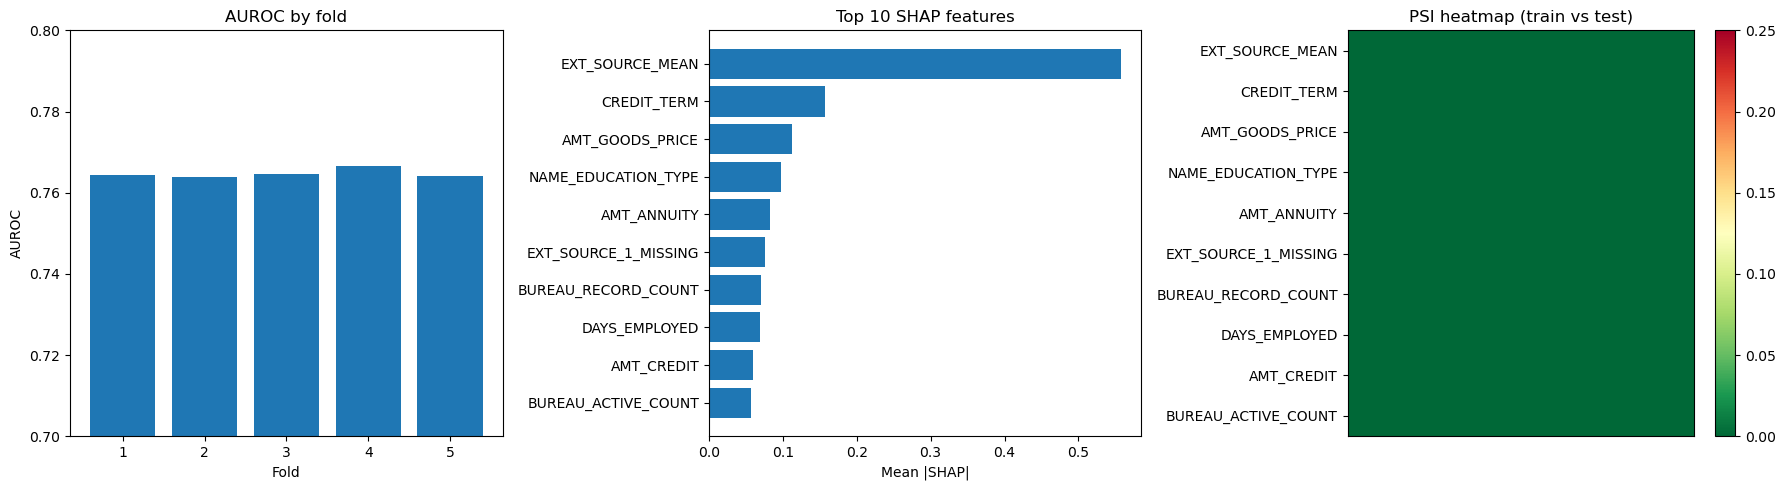

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(range(1, 6), cv_scores)
axes[0].set(title="AUROC by fold", xlabel="Fold", ylabel="AUROC", ylim=(0.7, 0.8))

top = importance.head(10).sort_values()
axes[1].barh(top.index, top.values)
axes[1].set(title="Top 10 SHAP features", xlabel="Mean |SHAP|")

im = axes[2].imshow(psi_table[["PSI"]], aspect="auto", cmap="RdYlGn_r", vmin=0, vmax=0.25)
axes[2].set(title="PSI heatmap (train vs test)", xticks=[])
axes[2].set_yticks(range(len(psi_table)), psi_table.index)
fig.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.show()